# Aprendizaje Estadístico y Data Mining

## Práctica 3: Especies de monos

### Objetivo
El etiquetado de imágenes es una tarea ardua. Es por ello y también debido a sus aplicaciones prácticas que los científicos llevan un tiempo intentando mejorar los métodos para clasificarlas automáticamente. En la aduana del aeropuerto de Madrid se intenta luchar contra el tráfico de animales exóticos. Para ello se va a crear un clasificador que realizando una foto a un animal (en este caso monos) pueda decidir si pertenece a una especie en peligro de extinción o no. Dicho clasificador funcionará mediante un set de entrenamiento donde se buscará un plano que divida las diferentes clases dispuesta en un espacio n-dimensional dependiendo de sus características. Muestra todos los resultados del algoritmo paso a paso.

Para ello usaremos el dataset **“monos.zip”** que se encuentra en *scikit-learn*. Elige el clasificador que más se adapte de entre los vistos en clase y usa *scikit-learn* junto con las librerías que necesites para resolver las siguientes cuestiones.

* [Link al dataset.](https://www.kaggle.com/datasets/slothkong/10-monkey-species?select=validation)

**Enunciado:**  Crea un clasificador que permita saber qué especie de mono es a partir de una imagen. Realiza al menos dos configuraciones y dibuja una tabla donde se muestre la precisión con la que clasifican.

**Solución**

Nuestro objetivo es construir y programar un sistema capaz de clasificar imágenes de monos en función de su especie, utilizando algoritmos clásicos de clasificación que hemos dado en clase como SVM, regresión logística y KNN. Para ello, vamos a convertir las imágenes en vectores de características que puedan ser entendidos por estos modelos.

Para empezar, vamos a importar todas las librerías que necesitamos, entre ellas:

- `PIL.Image` para procesar imágenes las imágenes de los monos.
- `numpy` y `pandas` para manipular los datos.
- `sklearn` para aplicar distintos clasificadores.

Luego, definimos las rutas de los datos de entrenamiento y validación. Estas imágenes ya vienen organizadas en carpetas según la especie a la que pertenecen.

Para cargar los datos de las fotos hemos creado una función `cargar_datos` que hace los siguientes:

1. Recorremos cada carpeta de la ruta que hemos indicado y asumimos que el nombre de la carpeta representa la clase (etiqueta).
2. Redimensionamos cada imagen al mismo tamaño (64x64) para estandarizarlas.
3. Convertimos las imágenes en arrays de `numpy`, normalizándolas a valores entre 0 y 1.
4. Vectorizamos cada imagen para poder introducirla en un clasificador.
5. Devolvemos dos arrays: uno con los datos de las imágenes y otro con sus etiquetas correspondientes.

También codificamos las etiquetas de texto (como `n0`, `n1`, ...) a valores numéricos, ya que los clasificadores no pueden operar directamente con strings.

In [2]:
# Importamos las librerías necesarias
import os
import numpy as np
import pandas as pd
from PIL import Image
from matplotlib import pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Definimos la ruta del archivo CSV
ENTRENAMIENTO_PATH = "data/monos_especies/training"
VALIDACION_PATH = "data/monos_especies/validation"

def cargar_datos(ruta_base: str, tamano_imagen=(64, 64)) -> tuple:
    """
    Carga los datos de una carpeta y los convierte en un array de numpy.
    Cada imagen se convierte a un array y se normaliza (0-1).

    Args:
        ruta_base (str): Ruta base donde se encuentran las carpetas de imágenes.
        tamano_imagen (tuple, optional): Tamaño al que se redimensionarán las imágenes. Por defecto (64, 64).

    Returns:
        tuple: Un tuple que contiene dos arrays de numpy:
            * datos: Array de imágenes vectorizadas.
            * etiquetas: Array de etiquetas correspondientes a las imágenes.
    """

    datos = []
    etiquetas = []

    # 1. Recorremos las carpetas de la ruta base
    for carpeta in os.listdir(ruta_base):
        etiqueta = carpeta
        carpeta_path = os.path.join(ruta_base, carpeta)

        # 2. Para cada carpeta, recorremos los archivos de imagen
        for fichero in os.listdir(carpeta_path):

            # 3. Generamos la ruta completa de la imagen
            imagen_path = os.path.join(carpeta_path, fichero)
            try:
                # 4. Abrimos la imagen para convertirla a un array
                imagen = Image.open(imagen_path).convert('RGB')

                # 5. Redimensionamos la imagen para que tenga el tamaño especificado
                imagen = imagen.resize(tamano_imagen)

                # 6. Convertimos la imagen a un array de numpy, lo normalizamos y lo vectorizamos
                # para que cada imagen tenga un tamaño fijo
                array_imagen = np.asarray(imagen) / 255.0  # Normalizamos
                datos.append(array_imagen.flatten())       # Vectorizamos

                # 7. Añadimos la etiqueta correspondiente a la lista de etiquetas
                # (la etiqueta es el nombre de la carpeta)
                etiquetas.append(etiqueta)
            except:
                pass # Ignoramos errores al abrir imágenes

    # 8. Devolvemos los datos y etiquetas como arrays de numpy
    return np.array(datos), np.array(etiquetas)


X_entrenamiento, y_entrenamiento = cargar_datos(ENTRENAMIENTO_PATH)
X_validacion, y_validacion = cargar_datos(VALIDACION_PATH)

# Codificamos las etiquetas de texto a números
# para que los clasificadores puedan trabajar con ellas
labelEncoder = LabelEncoder()
y_entrenamiento_codificado = labelEncoder.fit_transform(y_entrenamiento)
y_validacion_codificado = labelEncoder.transform(y_validacion)

A continuación, vamos a entrenar cuatro modelos diferentes con los mismos datos, para comparar su rendimiento:
1. **SVM con kernel lineal**: Utilizamos un modelo de *support vector machines* (SVM) con un kernel lineal. Este tipo de modelo intenta encontrar un hiperplano que separe las clases de forma lineal. Es un modelo útil cuando los datos son linealmente separables en un espacio de alta dimensión.

2. **SVM con kernel no lineal**: También hemos probado una variante de SVM con un kernel no lineal (RBF), que nos permite *crear fronteras de decisión no lineales*, lo que suele funcionar mejor cuando los datos son visuales o complejos.

3. **Regresión logística**: Es otro modelo lineal que se utiliza en clasificación multiclase. Intenta estimar probabilidades de pertenencia a cada clase. Es más interpretable, aunque a veces menos potente que SVM.

4. **KNN (K-Nearest Neighbors)**: Probamos también un modelo de *vecinos más cercanos (KNN)* con `k=5`. Este clasificador no aprende una función explícita: para clasificar una imagen nueva, busca las 5 imágenes más similares del conjunto de entrenamiento y vota la clase más común. Aunque es fácil de entender, suele escalar peor con muchos datos.

In [3]:
# 1. Support Vector Machine (SVM) con kernel lineal

# 1.1 Inicializamos el clasificador SVM con un kernel lineal
support_vector_machine_lineal = SVC(kernel='linear')
# 1.2 Entrenamos el clasificador SVM con los datos de entrenamiento
support_vector_machine_lineal.fit(X_entrenamiento, y_entrenamiento_codificado)
# 1.3 Realizamos predicciones sobre los datos de validación
y_predicha_svm = support_vector_machine_lineal.predict(X_validacion)
# 1.4 Calculamos la precisión del clasificador SVM comparando las etiquetas predichas con las etiquetas reales
accuracy_svm = accuracy_score(y_validacion_codificado, y_predicha_svm)


# 2. Support Vector Machine (SVM) con kernel no lineal

# 2.1 Inicializamos el clasificador SVM con un kernel no lineal
support_vector_machine_no_lineal = SVC(kernel='rbf')
# 2.2 Entrenamos el clasificador SVM con los datos de entrenamiento
support_vector_machine_no_lineal.fit(X_entrenamiento, y_entrenamiento_codificado)
# 2.3 Realizamos predicciones sobre los datos de validación
y_predicha_svm_no_lineal = support_vector_machine_no_lineal.predict(X_validacion)
# 2.4 Calculamos la precisión del clasificador SVM comparando las etiquetas predichas con las etiquetas reales
accuracy_svm_no_lineal = accuracy_score(y_validacion_codificado, y_predicha_svm_no_lineal)

# 3.1 Inicializamos el clasificador de regresión logística
# con un número máximo de iteraciones de 1000
regresion = LogisticRegression(max_iter=1000)
# 3.2 Entrenamos el clasificador de regresión logística con los datos de entrenamiento
regresion.fit(X_entrenamiento, y_entrenamiento_codificado)
# 3.3 Realizamos predicciones sobre los datos de validación
y_predicha_regresion = regresion.predict(X_validacion)
# 3.4 Calculamos la precisión del clasificador de regresión logística
accuracy_regresion = accuracy_score(y_validacion_codificado, y_predicha_regresion)

# 4. K-Nearest Neighbors (KNN)
# 4.1 Inicializamos el clasificador con k=5
knn = KNeighborsClassifier(n_neighbors=5)
# 4.2 Entrenamos el clasificador con los datos de entrenamiento
knn.fit(X_entrenamiento, y_entrenamiento_codificado)
# 4.3 Realizamos predicciones sobre los datos de validación
y_predicha_knn = knn.predict(X_validacion)
# 4.4 Calculamos la precisión del clasificador KNN
accuracy_knn = accuracy_score(y_validacion_codificado, y_predicha_knn)

c:\Users\rmore\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\rmore\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Finalmente, hemos construido una tabla comparativa (`df_resultados`) que nos muestra la precisión obtenida por cada modelo sobre el conjunto de validación de monos. Esto nos permite elegir el modelo más preciso para utilizarlo en la parte 2 para la clasificación de nuevas imágenes (que no han sido vistas durante el entrenamiento ni la validación).

In [4]:
# Tabla de resultados con la precisión de cada clasificador
df_resultados = pd.DataFrame({
    "Clasificador": ["SVM (lineal)", "SVM (no lineal)", "Regresión logística", "KNN (k=5)"],
    "Precisión (validación)": [
        f"{accuracy_svm:.2%}",
        f"{accuracy_svm_no_lineal:.2%}",
        f"{accuracy_regresion:.2%}",
        f"{accuracy_knn:.2%}"
    ]
})

display(df_resultados)

,Clasificador,Precisión (validación)
0,SVM (lineal),58.46%
1,SVM (no lineal),56.25%
2,Regresión logística,57.72%
3,KNN (k=5),32.35%


Tras entrenar y evaluar cuatro clasificadores distintos sobre el conjunto de validación, hemos obtenido los siguientes resultados de precisión:

| Clasificador             | Precisión (validación) |
|--------------------------|------------------------|
| SVM (lineal)             | 58.46%                 |
| SVM (no lineal, RBF)     | 56.25%                 |
| Regresión logística      | 57.72%                 |
| K-Nearest Neighbors (k=5)| 32.35%                 |

* El clasificador que mejor ha funcionado ha sido el *SVM con kernel lineal*, con una precisión del **58.46%**, ligeramente por encima del resto.

* La *regresión logística* ha conoseguido un rendimiento muy similar al SVM lineal, lo que tiene sentido, ya que ambos son clasificadores lineales que se comportan de manera parecida en problemas con clases relativamente separables.

* Sorprendentemente, el *SVM con kernel RBF (no lineal)* no ha superado al lineal, lo que nos indica que los datos, una vez vectorizados desde imágenes, no necesitan una frontera de decisión no lineal compleja.

* El rendimiento del *clasificador KNN* (32.35%) ha sido claramente inferior, probablemente debido a:
  * La alta dimensionalidad de los datos (cada imagen se convierte en miles de atributos).
  
  * La sensibilidad de KNN a datos ruidosos y poco discriminativos en espacios vectoriales tan grandes.

Estos resultados nos han demostrado que, incluso sin técnicas avanzadas de extracción de características, clasificadores clásicos como SVM y regresión logística pueden ofrecer un rendimiento aceptable en tareas de clasificación de imágenes. No obstante, también nos evidencia las limitaciones de estos métodos cuando los apllicamos directamente a imágenes "crudas", sin utilizar técnicas especializadas como redes convolucionales o ingeniería de características visuales.

**Enunciado:** Elige 5 imágenes de diferentes especies que no hayas usado ni para entrenar el modelo, ni para evaluarlo y clasifícalas. Usa para ello el modelo que mejor clasifique de los del punto anterior. Índica con que error ha funcionado el clasificador.

**Solución**

En esta sección vamos a comprobar la capacidad de generalización del modelo que hemos entrenado. Para ello, vamos usar imágenes de monos famosos que no hemos utilizado en el entrenamiento ni en la validación. El objetivo es comprobar si el modelo es capaz de realizar predicciones razonables sobre nuevos datos, incluso sin conocer su especie real con certeza.

Al igual que en la sección anterior, hemos definido e implementado una función `cargar_imagenes_test` en la que:

1. Leemos todas las imágenes de una carpeta específica (`data/monos_famosos`).
2. Redimensionamos cada imagen al mismo tamaño usado en entrenamiento (64x64 píxeles).
3. Convertimos las imágenes en arrays y las normalizamos a valores entre 0 y 1.
4. Vectorizamos las imágenes para poder introducirlas en los clasificadores previamente entrenados

> Como las imágenes son de monos conocidos (por ejemplo, personajes de películas o series), no conocemos con certeza su especie. Por eso, no evaluamos precisión ni error, sino que se observamos simplemente qué predice el modelo y si tiene sentido o no.

In [9]:
MONOS_FAMOSOS_PATH = "data/monos_famosos"

def cargar_imagenes_test(ruta_test: str, tamano_imagen=(64, 64)) -> tuple:
    """
    Carga los datos de una carpeta y los convierte en un array de numpy.
    Cada imagen se convierte a un array y se normaliza (0-1).

    Args:
        ruta_test (str): Ruta base donde se encuentran las carpetas de imágenes.
        tamano_imagen (tuple, optional): Tamaño al que se redimensionarán las imágenes. Por defecto (64, 64).

    Returns:
        tuple: Un tuple que contiene dos arrays de numpy:
            * datos: Array de imágenes vectorizadas.
            * etiquetas: Array de etiquetas correspondientes a las imágenes.
    """
    imagenes = []
    archivos = []

    for imagen in os.listdir(ruta_test):
        imagen_path = os.path.join(ruta_test, imagen)
        try:
            img = Image.open(imagen_path).convert('RGB')
            img = img.resize(tamano_imagen)
            img_array = np.asarray(img) / 255.0
            imagenes.append(img_array.flatten())
            archivos.append(imagen_path)
        except:
            print(f"Error con la imagen: {imagen_path}")

    return np.array(imagenes), archivos

X_prueba_monos_famosos, rutas_imagenes = cargar_imagenes_test(MONOS_FAMOSOS_PATH)

A partir de la tabla `df_resultados` que hemos generado en la primera parte, seleccionamos automáticamente el modelo que consiguió mayor precisión en validación. Esta estrategia nos permite aplicar siempre el clasificador más efectivo sobre los nuevos datos.

Clasificamos el conjunto de datos famosos con el modelo que consiguió mayor precisión, y luego realizamos una visualización con `matplotlib` para mostrar:

* La imagen del mono.
* La especie que el modelo ha predicho para esa imagen.

Esto nos permite mostrar de una forma visual e intuitiva si las predicciones tienen sentido, incluso sin conocer la especie real. Además, imprimimos en texto el nombre del archivo y la predicción correspondiente, para documentarlo fácilmente.

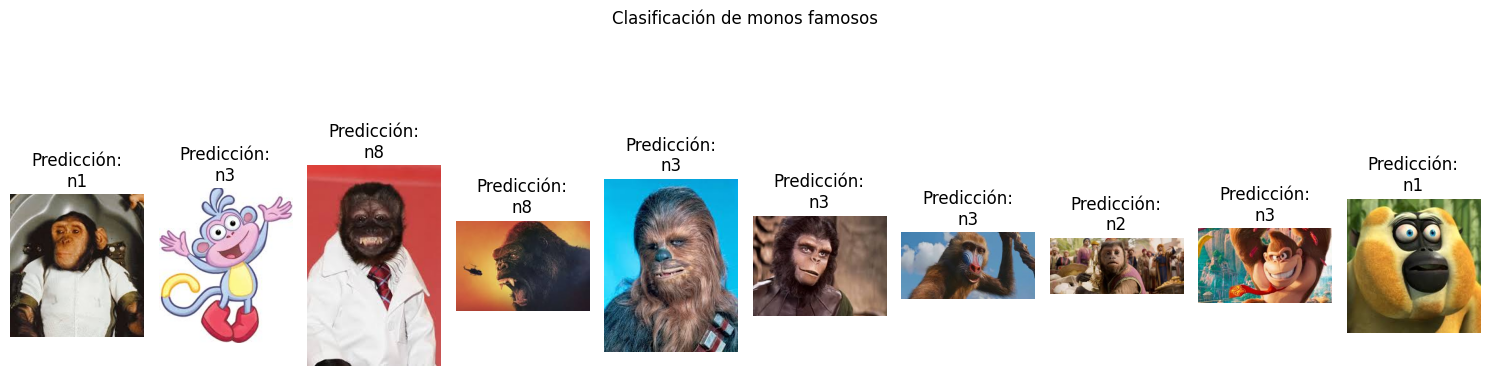

Resultados:
Imagen 1: archivo = Mono1.jpg → Predicha: n1
Imagen 2: archivo = Mono10.jpg → Predicha: n3
Imagen 3: archivo = Mono2.jpg → Predicha: n8
Imagen 4: archivo = Mono3.jpg → Predicha: n8
Imagen 5: archivo = Mono4.jpg → Predicha: n3
Imagen 6: archivo = Mono5.jpg → Predicha: n3
Imagen 7: archivo = Mono6.jpg → Predicha: n3
Imagen 8: archivo = Mono7.jpg → Predicha: n2
Imagen 9: archivo = Mono8.jpg → Predicha: n3
Imagen 10: archivo = Mono9.jpg → Predicha: n1


In [10]:
# Elegimos el mejor modelo de los que hemos entrenado
mejor_modelo_nombre = df_resultados.sort_values("Precisión (validación)", ascending=False).iloc[0]["Clasificador"]

if mejor_modelo_nombre == "SVM (lineal)":
    mejor_modelo = support_vector_machine_lineal
elif mejor_modelo_nombre == "SVM (no lineal)":
    mejor_modelo = support_vector_machine_no_lineal
elif mejor_modelo_nombre == "Regresión logística":
    mejor_modelo = regresion
elif mejor_modelo_nombre == "KNN (k=5)":
    mejor_modelo = knn
else:
    raise ValueError("Clasificador no reconocido.")

# Predecimos las especies de los 10 monos famosos
y_predicha_monos_famosos = mejor_modelo.predict(X_prueba_monos_famosos)
etiquetas_predichas = labelEncoder.inverse_transform(y_predicha_monos_famosos)

# Visualizamos los resultados
n_imagenes = len(X_prueba_monos_famosos)
plt.figure(figsize=(15, 5))

# Ajustamos el número de imágenes a mostrar (máximo 5)
for mono_famoso in range(n_imagenes):
    plt.subplot(1, n_imagenes, mono_famoso + 1)
    imagen = Image.open(rutas_imagenes[mono_famoso])
    plt.imshow(imagen)
    plt.axis('off')
    plt.title(f"Predicción:\n{etiquetas_predichas[mono_famoso]}")
plt.suptitle("Clasificación de monos famosos")
plt.tight_layout()
plt.show()

# Imprimimos los resultados
print("Resultados:")
for mono_famoso in range(len(X_prueba_monos_famosos)):
    print(f"Imagen {mono_famoso+1}: archivo = {os.path.basename(rutas_imagenes[mono_famoso])} → Predicha: {etiquetas_predichas[mono_famoso]}")


Vamos a analizar los resultados que hemos obtenido al clasificar las imágenes de monos famosos.

* La primera imagen clasificada como n1 corresponde a Ham, el primer chimpancé astronauta. La forma general de su cara y las orejas grandes pueden haber inducido al modelo a considerarlo visualmente similar. Además, el traje blanco que lleva puesto refuerza el contraste claro-oscuro típico del pelaje de los monos patas, lo que podría haber influido en la clasificación. A pesar de que la especie no coincide, la predicción del modelo es razonable desde una perspectiva visual.

* La única imagen clasificada como n2 corresponde al mono de la película Aladdín, una representación ficticia del personaje Abu. Aunque no existe una correspondencia biológica directa, su diseño presenta una cara clara y expresiva, con pelaje marrón rojizo, lo que podría haber recordado al modelo a la especie representada por la clase n2, el mono uacarí rojo, conocido por su rostro rojizo desnudo y pelaje anaranjado. La predicción, aunque es incorrecta, tiene cierta lógica visual, ya que el modelo parece haber captado patrones cromáticos dominantes y contrastes faciales similares. Este resultado refleja tanto su capacidad para identificar rasgos visuales generales como sus limitaciones al carecer de comprensión semántica real del contenido.

* La imagen que corresponde al mono de “Los Cinco Furiosos” de la película Kung Fu Panda se trata de un personaje completamente ficticio y animado, pero con una estética que incluye un rostro oscuro muy marcado y mejillas anaranjadas claras, lo cual guarda un gran parecido con los rasgos cromáticos del mono patas (clase n1). Sorprendentemente, el modelo ha conseguido identificar estos elementos visuales esenciales y generalizar su conocimiento incluso a una figura de animación que nunca ha sido parte del conjunto de entrenamiento ni validación.

* El modelo ha clasificado como especie n3 a varias imágenes, incluyendo a Chewbacca (Star Wars), un personaje del Planeta de los Simios, el mandril de El Rey León (Rafiki), Donkey Kong y Botas (el mono de Dora la Exploradora). Aunque ninguno de estos personajes es un mono real, presentan rasgos visuales que podrían coincidir con los ejemplares reales de la clase n3 del dataset, correspondiente al macaco japonés, también conocido como “mono de las nieves”. Esta especie se caracteriza por su pelaje denso, de tonos grises o marrones claros, y un rostro rosado y redondeado. Visualmente, varios de estos personajes muestran combinaciones similares: Visualmente, varios de estos personajes comparten similitudes con esas características: Chewbacca y Donkey Kong tienen pelajes abundantes y una estructura corporal robusta, Rafiki presenta una cara llamativa y redondeada con marcados contrastes de color, los simios del Planeta de los Simios están diseñados con rostros expresivos y pelaje espeso, y Botas tiene una cara clara con formas simples y grandes ojos, que pueden recordar a la cara del macaco. Por tanto, si bien las predicciones no son correctas desde una perspectiva biológica, son comprensibles a nivel de similitud visual general, lo que demuestra la capacidad del modelo para abstraer ciertos rasgos en contextos visualmente distintos.

* El modelo ha clasificado como especie n8 a Crystal, la mona de las películas de Noche en el museo, y a King Konge. En el dataset, la clase n8 representa al mono nocturno (Aotus), también conocido como "mono búho", una especie de pequeño tamaño con grandes ojos oscuros adaptados a la visión nocturna, pelaje corto y denso de tonos grises o marrones, y un patrón facial distintivo en forma de máscara clara. Desde una perspectiva biológica, la predicción no tiene sentido, ya que King Kong representa a un gorila de enormes proporciones y Crystal es un mono capuchino, pero ambas imágenes comparten rasgos visuales que podrían justificar la clasificación: en el caso de Crystal, el pelaje oscuro, los ojos prominentes y la expresión facial pueden evocar al mono búho, mientras que King Kong, pese a su tamaño y carácter ficticio, presenta un rostro oscuro con rasgos marcados y una estructura facial simplificada que el modelo puede haber interpretado como similar. Esta clasificación resalta nuevamente cómo el modelo no comprende las especies como tal, sino que reacciona a patrones visuales como colores oscuros, proporciones faciales o densidad de pelaje, aplicando lo aprendido incluso en contextos irreales.

A lo largo de esta práctica hemos comprobado que, aunque los clasificadores que hemos utilizado no poseen conocimiento semántico ni biológico real, sí son capaces de identificar patrones visuales consistentes entre especies y extrapolarlos a imágenes externas, incluso cuando se trata de personajes ficticios o caricaturizados. Esto demuestra tanto su poder de generalización como sus limitaciones, dejando claro que estos modelos pueden ser útiles para tareas de clasificación básica, pero no sustituyen una comprensión profunda del contexto ni una taxonomía precisa.